In [1]:
# In this example projected 2D domain of a 4D Henon map is constructed
# The 2D domain records a projection (more precisely, a finite-thickness slice followed by a projection) of the 4D dynamics
# Giving a robust 2D stable region enclosure
# Independent radial searches and local resampling accumulate the projected bounding set
# Ray filtering keeps the first occupied cell on each angular ray as the active boundary
# The boundary of the accumulated set becomes a sampling shell
# Repeated forward and inverse propagation from that shell grows the projected transport skeleton
# The final plots compare the bounding set, shell, and the two time directions

In [2]:
# Import 

from tqdm import tqdm

import numpy as np
from numpy.typing import NDArray
from numba import njit

from matplotlib import pyplot as plt
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True
from matplotlib.patches import Rectangle
from matplotlib.patches import Circle

from domain.scan import iterate
from domain.scan import count
from domain.scan import scan
from domain.scan import orbit

from domain.da import da
from domain.da import refine

from domain.volume import rays
from domain.volume import directions
from domain.volume import volume

from domain.sample import sample
from domain.sample import mask
from domain.sample import filter
from domain.sample import select
from domain.domain import Domain

from domain import Configuration
from domain import Result
from domain import compute

In [3]:
# Set global parameters

projection_dimension = 2                 # -- dimension of the stored qx-qy domain
map_dimension = 4                        # -- dimension of the Henon map
width = 1                                # -- half-thickness of the px=py=0 slice, in cells
epsilon = 1.0E-6                         # -- slice tolerance
dl = 0.01                                # -- domain cell side length
dr = dl*projection_dimension**0.5        # -- radial step in the qx-qy initial plane
lb = np.array([-1.5, -1.5])              # -- projected-domain lower bounds for (qx, qy)
ub = np.array([+1.5, +1.5])              # -- projected-domain upper bounds for (qx, qy)
size = 16384                             # -- total number of map iterations
ndirections = 8                          # -- random initial directions in the qx-qy plane
nsamples = 2048                          # -- marked cells sampled per expansion round
npoints = 8                              # -- initial conditions generated per selected cell
nrounds = 128                            # -- maximum expansion rounds per epoch
nepochs = 32                             # -- independent initial-ray epochs
growth_epochs = 32                       # -- post-construction transport-growth epochs
batch = 256                              # -- bound orbit-buffer memory usage
center = np.zeros(projection_dimension)  # -- center of the projected domain
map_center = np.zeros(map_dimension)     # -- corresponding center in the 4D map
cut = 2.0                                # -- retained-orbit radius
threshold = 5.0                          # -- escape radius
termination = 0.99                       # -- required fraction of rays hitting the domain
scale = 3.0                              # -- local perturbation scale in cell units
bins_plane = 16                          # -- number of bins for the mixing coordinate
bins_phase = 32                          # -- number of bins for the in-plane phases
phase_threshold = 1.0E-3                 # -- phase threshold used in weighted selection
alpha_plane = 1.0                        # -- plane weight factor
alpha_phase = 0.5                        # -- phase weight factor
boost = 0.5                              # -- weight boost near the edges
delta = 1.0                              # -- inverse-density score regularization
uniform = 0.05                           # -- fraction of uniform sampling to use
power = 1.0                              # -- score power
uniform = 0.05                           # -- fraction of uniform sampling

In [4]:
#  Define 4D Henon symplectic mapping

@njit
def forward(
    x:NDArray[np.float64], 
    parameters:NDArray[np.float64]
) -> NDArray[np.float64]:
    """
    4D Henon symplectic mapping

    Parameters
    ----------
    x: NDArray[np.float64], (dimension, )
        initial condition
    parameters: NDArray[np.float64]
        mapping parameters

    Returns
    -------
    NDArray[np.float64]

    """
    qx, qy, px, py = x
    cx, sx, cy, sy, mu = parameters
    Qx = cx*qx + sx*(px + qx**2 - qy**2 + mu*(qx**3 - 3*qx*qy**2))
    Qy = cy*qy + sy*(py - 2*qx*qy + mu*(-3*qx**2*qy + qy**3))
    Px = cx*(px + qx**2 - qy**2 + mu*(qx**3 - 3*qx*qy**2)) - sx*qx
    Py = cy*(py - 2*qx*qy + mu*(-3*qx**2*qy + qy**3)) - sy*qy
    return np.array([Qx, Qy, Px, Py])

In [5]:
@njit
def inverse(
    x: NDArray[np.float64], 
    parameters: NDArray[np.float64]
) -> NDArray[np.float64]:
    """
    4D Henon symplectic mapping (inverse)

    Parameters
    ----------
    x: NDArray[np.float64], (dimension, )
        initial condition
    parameters: NDArray[np.float64]
        mapping parameters

    Returns
    -------
    NDArray[np.float64]

    """
    qx, qy, px, py = x
    cx, sx, cy, sy, mu = parameters
    Qx = cx*qx - sx*px
    Qy = cy*qy - sy*py
    Px = cx*px + sx*qx - Qx**2 + Qy**2 - mu*(Qx**3 - 3*Qx*Qy**2)
    Py = cy*py + sy*qy + 2*Qx*Qy - mu*(-3*Qx**2*Qy + Qy**3)
    return np.array([Qx, Qy, Px, Py])

In [6]:
# Set mapping parameters

nux, nuy = 0.168, 0.201
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 1.0
knobs = np.asarray([cx, sx, cy, sy, mu])

In [7]:
# Define the objective function
# Returns True if the initial condition is not NaN and stays within the hyperball of the given radius

objective = iterate(size, threshold, forward)

zero = np.array([0.0, 0.0, 0.0, 0.0])

print(objective(zero + 0.0*threshold, knobs))
print(objective(zero + 1.0*threshold, knobs))

True
False


In [8]:
# Define the complexity function (number of stable iterations)
# The number of mapping invocations is greater by one

complexity_forward = count(size, threshold, forward)
complexity_inverse = count(size, threshold, inverse)

print(complexity_forward(zero + 0.0*threshold, knobs))
print(complexity_forward(zero + 1.0*threshold, knobs))

16384
0


In [9]:
# Define auxilary functions

def lift(points, map_dimension=map_dimension, projection_dimension=projection_dimension):
    """ Embed projected qx-qy points in the px=py=0 initial plane """
    points = np.asarray(points, dtype=np.float64).reshape(-1, projection_dimension)
    lifted = np.zeros((len(points), map_dimension), dtype=np.float64)
    lifted[:, :projection_dimension] = points
    return lifted


def project(points, cell, width=width, epsilon=epsilon, cut=cut, map_dimension=map_dimension, projection_dimension=projection_dimension):
    """ Take the finite-radius px=py=0 slice of a 4D orbit cloud """
    points = np.asarray(points, dtype=np.float64).reshape(-1, map_dimension)
    if len(points) == 0:
        return np.empty((0, projection_dimension), dtype=np.float64)
    points = filter(points, cut)
    if len(points) == 0:
        return np.empty((0, projection_dimension), dtype=np.float64)
    thickness = width*cell + epsilon
    keep = np.all(np.abs(points[:, projection_dimension:]) < thickness, axis=1)
    projected = np.ascontiguousarray(points[keep, :projection_dimension])
    return filter(projected, cut)


def collect(initial, generator, cell, batch=batch, map_dimension=map_dimension, projection_dimension=projection_dimension):
    """ Return projected pre-escape iterates without an oversized orbit buffer """
    chunks = []
    for start in range(0, len(initial), batch):
        local = np.ascontiguousarray(initial[start:start + batch])
        buffer = np.empty((len(local), size, map_dimension), dtype=np.float64)
        scan(local, buffer, generator, knobs)
        lost = mask(buffer, threshold)
        if np.any(lost):
            projected = project(buffer[lost].reshape(-1, map_dimension), cell)
            if len(projected):
                chunks.append(projected)
    if not chunks:
        return np.empty((0, projection_dimension), dtype=np.float64)
    return np.vstack(chunks)


In [10]:
# Construct the projected bounding set over independent epochs

container = Domain(lb, ub, dl)
result = Result(data=[], costs=None, rads=[], cells=[], container=container)

forward_generator = orbit(size, threshold, forward)
inverse_generator = orbit(size, threshold, inverse)

pairs = [(256, 256)]

for epoch in range(nepochs):
    ds = directions(projection_dimension, ndirections)
    ds = lift(ds)
    _, unstable = da(map_dimension, dr, threshold, map_center, ds, objective, knobs, unstable=True)
    points = collect(unstable, forward_generator, dl)
    print()
    print(f'epoch: {epoch + 1:02d}')
    print(f'initial projected points: {len(points):d}')
    print()
    domains = []
    for cell in [dl]:
        local = Domain(lb, ub, cell)
        local.update(points)
        domains.append(local)
        print(f'ocupation: {local.size:d}/{local.total:d}')
    container.update(points)
    epoch_data = []
    epoch_rads = []
    while domains:
        domain, *_ = domains
        if domain.size == 0:
            domain = domains.pop(0)
            result.cells.append(domain)
            result.data.append(epoch_data)
            result.rads.append(epoch_rads)
            continue    
        cell = domain.cell
        for pair in pairs:
            ds, _ = rays(projection_dimension, *pair)
            for i in range(nrounds):
                indices = np.random.choice(domain.list, nsamples)
                centers = domain.transform(indices)
                initial = lift(sample(npoints, scale*cell, centers))
                points = collect(initial, forward_generator, cell)        
                for domain in domains:
                    domain.update(points)
                container.update(points)
                domain, *_ = domains
                keys, rads, _ = domain.boundary(*pair, center, ds)
                hits = keys >= 0
                flag = int(np.sum(~hits))
                rads = rads[hits]
                radius = float(np.mean(rads**projection_dimension)**(1/projection_dimension))
                domain = Domain(lb, ub, dl)
                domain.insert(keys[hits])
                _, *domains = domains
                domains = [domain] + domains
                epoch_data.append(np.asarray([flag, domain.size, len(ds)]))
                epoch_rads.append(radius)
                print(f' {i + 1:03d} {domain.size:8d} {flag:8d} {100*flag/len(ds):8.2f} {container.size:8d} {radius:.6f}')
                if domain.size == 0:
                    break
                if flag <= (1.0 - termination)*len(ds):
                    break
        domain = domains.pop(0)
        result.cells.append(domain)
        result.data.append(epoch_data)
        result.rads.append(epoch_rads)


epoch: 01
initial projected points: 30

ocupation: 25/90601
 001      218       30    11.72     1402 0.520691
 002      248        0     0.00     2090 0.499377

epoch: 02
initial projected points: 6

ocupation: 6/90601
 001      188       63    24.61     2441 0.547063
 002      227       17     6.64     2575 0.525835
 003      244        4     1.56     2704 0.501966
 004      248        0     0.00     2841 0.494733

epoch: 03
initial projected points: 10

ocupation: 9/90601
 001      166       90    35.16     3053 0.572024
 002      220       23     8.98     3165 0.524861
 003      240        4     1.56     3246 0.503638
 004      247        0     0.00     3310 0.495009

epoch: 04
initial projected points: 6

ocupation: 6/90601
 001      199       49    19.14     3414 0.513750
 002      240        5     1.95     3487 0.499992
 003      244        0     0.00     3535 0.494623

epoch: 05
initial projected points: 50

ocupation: 29/90601
 001      230       14     5.47     3581 0.505397


In [11]:
# Construct final shell from the accumulated domain

pair = (256, 256)
ds, _ = rays(projection_dimension, *pair)
keys, rads, _ = result.container.boundary(*pair, center, ds)

shell = Domain(lb, ub, dl)
shell.insert(np.unique(keys[keys >= 0]))

print(shell.size)
print(np.sum(keys < 0))

243
0


In [12]:
# Grow (forward)

domain_forward = Domain(lb, ub, dl)
domain_forward.insert(shell.keys)

for epoch in range(growth_epochs):
    if domain_forward.size == 0:
        break
    indices = np.random.choice(domain_forward.list, nsamples)
    centers = domain_forward.transform(indices)
    initial = lift(sample(npoints, scale*dl, centers))
    points = collect(initial, forward_generator, dl)
    previous = domain_forward.size
    domain_forward.update(points)
    print(f'{epoch + 1:02d} {domain_forward.size:8d} + {domain_forward.size - previous:d}')
    if domain_forward.size == domain_forward.total:
        break

01     1362 + 1119
02     2017 + 655
03     2426 + 409
04     2694 + 268
05     2920 + 226
06     3122 + 202
07     3292 + 170
08     3435 + 143
09     3554 + 119
10     3696 + 142
11     3810 + 114
12     3902 + 92
13     3996 + 94
14     4095 + 99
15     4195 + 100
16     4281 + 86
17     4354 + 73
18     4430 + 76
19     4496 + 66
20     4556 + 60
21     4620 + 64
22     4676 + 56
23     4737 + 61
24     4790 + 53
25     4841 + 51
26     4885 + 44
27     4939 + 54
28     4984 + 45
29     5039 + 55
30     5077 + 38
31     5119 + 42
32     5165 + 46


In [13]:
# Grow (inverse)

domain_inverse = Domain(lb, ub, dl)
domain_inverse.insert(shell.keys)

for epoch in range(growth_epochs):
    if domain_inverse.size == 0:
        break
    indices = np.random.choice(domain_inverse.list, nsamples)
    centers = domain_inverse.transform(indices)
    initial = lift(sample(npoints, scale*dl, centers))
    points = collect(initial, inverse_generator, dl)
    previous = domain_inverse.size
    domain_inverse.update(points)
    print(f'{epoch + 1:02d} {domain_inverse.size:8d} + {domain_inverse.size - previous:d}')
    if domain_inverse.size == domain_inverse.total:
        break

01     1388 + 1145
02     1976 + 588
03     2387 + 411
04     2680 + 293
05     2900 + 220
06     3048 + 148
07     3189 + 141
08     3309 + 120
09     3431 + 122
10     3527 + 96
11     3597 + 70
12     3669 + 72
13     3739 + 70
14     3787 + 48
15     3860 + 73
16     3916 + 56
17     3977 + 61
18     4017 + 40
19     4061 + 44
20     4107 + 46
21     4139 + 32
22     4185 + 46
23     4230 + 45
24     4263 + 33
25     4293 + 30
26     4323 + 30
27     4353 + 30
28     4382 + 29
29     4404 + 22
30     4431 + 27
31     4456 + 25
32     4480 + 24


In [14]:
# Construct point

Qx_shell, Qy_shell = shell.construct.T
Qx_forward, Qy_forward = domain_forward.construct.T
Qx_inverse, Qy_inverse = domain_inverse.construct.T

In [15]:
# Compute survival map

n = 1000
qx = np.linspace(-1.5, 1.5, n)
qy = np.linspace(-1.5, 1.5, n)
qxqy = np.stack(np.meshgrid(qx, qy, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
pxpy = np.full_like(qxqy, 0.0)
qx, qy = qxqy.T
px, py = pxpy.T
xs = np.stack([qx, qy, px, py]).T

mask_qxqy = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qxqy, complexity_forward, knobs)

mask_qxqy_inverse = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, mask_qxqy_inverse, complexity_inverse, knobs)

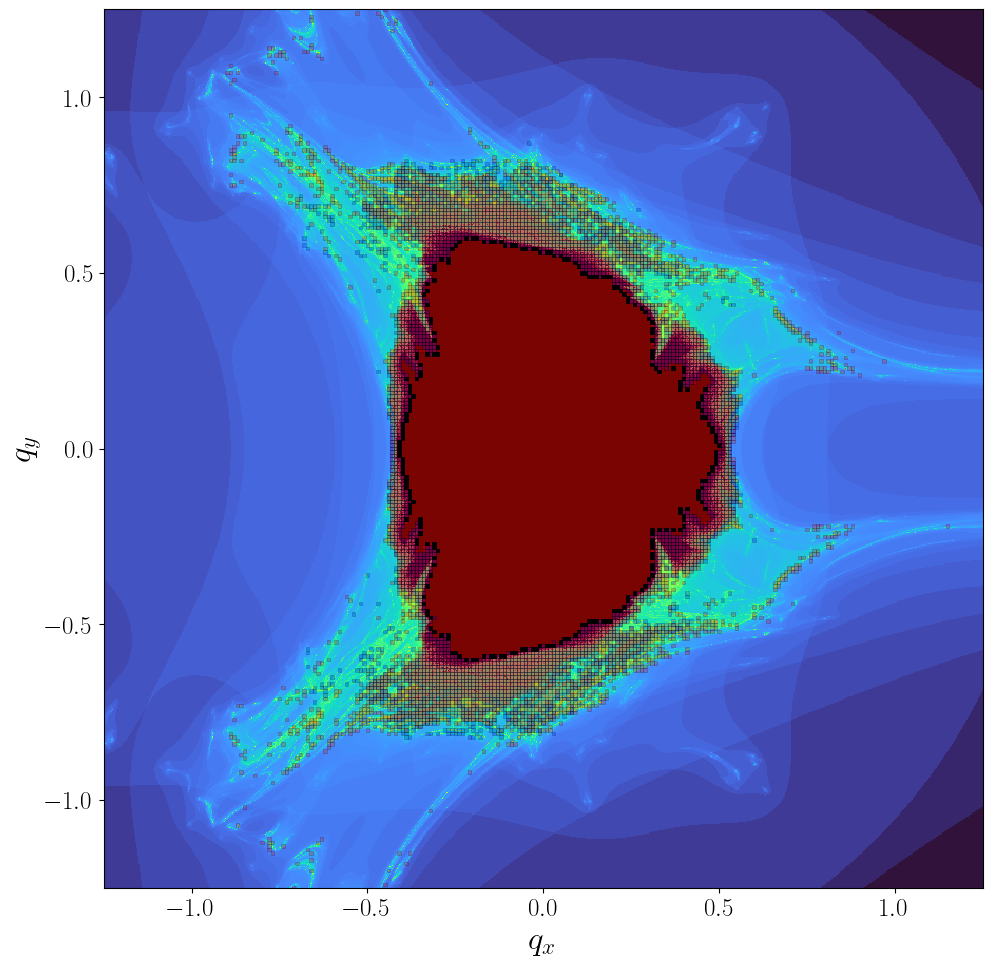

In [16]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(np.log10(1 + 1/2*(mask_qxqy + mask_qxqy_inverse)).reshape(n, n), aspect='equal', origin='lower', cmap='turbo', interpolation='nearest', extent=(-1.5, 1.5, -1.5, 1.5), zorder=0)
for cx, cy in domain_forward.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="red", edgecolor="black", linewidth=0.5, alpha=0.25, zorder=1))
for cx, cy in domain_inverse.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="blue", edgecolor="black", linewidth=0.5, alpha=0.25, zorder=1))
for cx, cy in shell.construct:
    ax.add_patch(Rectangle((cx - 0.5 * dl, cy - 0.5 * dl), dl, dl, facecolor="black", edgecolor="black", linewidth=0.5, alpha=1, zorder=2))
plt.xlabel('qx')
plt.ylabel('qy')
plt.xlim(-1.25, 1.25)
plt.ylim(-1.25, 1.25)
plt.xlabel(r"$q_x$", fontsize=24)
plt.ylabel(r"$q_y$", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()